In [1]:
# Python Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from numpy.random import poisson
from matplotlib.path import Path


from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

import autofit as af
import autolens as al
import autolens.plot as aplt

%matplotlib inline

/home/joao/Documents/Research/4_sys_analysis
Working Directory has been set to `/home/joao/Documents/Research/4_sys_analysis`


2021-09-05 22:36:29,567 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autofit/config


2021-09-05 22:36:29,909 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autoarray/config
2021-09-05 22:36:29,975 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autogalaxy/config
2021-09-05 22:36:30,032 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autolens/config


In [2]:
#N_iter=10000
grid_scale = 0.1

In [3]:
def rotate_matrix(m):
    return [[m[j][i] for j in range(len(m))] for i in range(len(m[0])-1,-1,-1)]

In [4]:
def prepare_data(path, img_name, psf_name, out_name, mask_circular=True, radius=4.0):
    """
    path: str path of imgblocks
    img_name: fits image name
    psf_name: fits psf name
    mask_circular: binary var that represents the method of our mask
    radius: mask radius in case of mask_circular True
    """
    
    width = 150
    height = 150
    # read an image from fits
    image = al.Array2D.from_fits(file_path=path+img_name,
                                 pixel_scales=grid_scale,
                                 hdu=0) # hdu from 3
    # noise map
    noise_image = np.ones(len(image))*0.5 # filled with 0.5
    noise_map = al.Array2D.manual_slim(noise_image, pixel_scales=grid_scale, shape_native=image.shape_native)
    # psf
    psf = al.Kernel2D.from_fits(file_path=path+psf_name,
                                hdu=0,
                                pixel_scales=grid_scale)
    # reescale the psf
    new_psf=psf.rescaled_with_odd_dimensions_from_rescale_factor(rescale_factor=1)
    # image object
    imaging = al.Imaging(image=image, psf=new_psf, noise_map=noise_map)
    

    
    print(image.shape_native)
    
    
    file = open(path+out_name)
    lines = file.readlines()
    file.close()

    polygon=[]
    for i in range(0, len(lines)):
        if lines[i].startswith("polygon"):
            polygon.append(np.array(lines[i][8:-2].split(",")).astype(np.float))

    for i in range(0, len(polygon)):
        polygon[i] = polygon[i].reshape(int(len(polygon[i])/2),2)


    for i in range(0, len(polygon)):
        for j in range(0, len(polygon[i])):
            polygon[i][j] = tuple(polygon[i][j])

    final_mask=np.zeros(22500).reshape(150,150)
    for i in range(0, len(polygon)):
        poly_path=Path(polygon[i])

        x, y = np.mgrid[:height, :width]
        coors=np.hstack((x.reshape(-1, 1), y.reshape(-1,1))) # coors.shape is (4000000,2)

        mask = poly_path.contains_points(coors)
        new_mask=rotate_matrix(mask.reshape(150, 150))
        final_mask = final_mask+new_mask

    mask=al.Mask2D.manual(1-final_mask, pixel_scales=imaging.pixel_scales)
    
    
    
    
    #if mask_circular:
        #mask = al.Mask2D.circular(shape_native=imaging.shape_native,
                                  #pixel_scales=imaging.pixel_scales,
                                  #radius=radius)
                
    imaging = imaging.apply_mask(mask=mask)
    return imaging

In [5]:
def prepare_model(lens_redshift, source_redshift=1., dm_imput=False):
    """
    source_redshift: float source redshift value
    lens_redshift: float lens redshift value
    dm_imput: boolean parameter for dark matter modelization
    """
    # source galaxy model
    source_galaxy_model = af.Model(al.Galaxy,
                               redshift=source_redshift,
                               disk=al.lp.EllExponential)
    
    if dm_imput:
        dark = af.Model(al.mp.EllNFW)
        bulge = af.Model(al.lp.EllDevVaucouleurs)
        bulge.centre = dark.centre
        # lens galaxy model
        lens_galaxy_model = af.Model(al.Galaxy,
                                 redshift=lens_redshift,
                                 bulge=bulge,
                                 mass=al.mp.EllIsothermal,
                                 dark=dark)
    else:
        bulge = af.Model(al.lp.EllDevVaucouleurs)
        lens_galaxy_model = af.Model(al.Galaxy,
                                 redshift=lens_redshift,
                                 bulge=bulge,
                                 mass=al.mp.EllIsothermal)
    
    
    return af.Collection(galaxies=af.Collection(lens=lens_galaxy_model, source=source_galaxy_model))


## CS82SL013639.16+000818.38

In [6]:
imgblocks_paths = "./imgblocks/sys_1/" # imgblocks path
img_name = "resid.fits" # specific imgblock
psf_img_name = "psf2.fits" # psf
reg_contours = "sys_1.reg"

In [7]:
img_1 = prepare_data(imgblocks_paths, img_name, psf_img_name, reg_contours)

(150, 150)


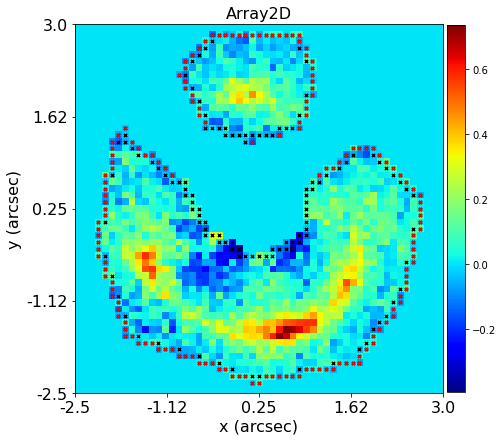

In [8]:
# fits plot
array_plotter = aplt.Array2DPlotter(array=img_1.image)
array_plotter.figure_2d()

In [9]:
model = prepare_model(0.344)

In [10]:
search = af.DynestyStatic(
    path_prefix="./",
    name="sys_1_dist",
    unique_tag="sys_1_dist",
    nlive=500,
    number_of_cores=6,
)
analysis = al.AnalysisImaging(dataset=img_1)

result = search.fit(model=model, analysis=analysis)

2021-09-05 22:36:31,335 - sys_1_dist - INFO - Creating search
2021-09-05 22:36:31,336 - sys_1_dist - INFO - Starting search
2021-09-05 22:36:31,338 - sys_1_dist - INFO - Saving path info
2021-09-05 22:36:31,368 - sys_1_dist - INFO - Not complete. Starting non-linear search.
2021-09-05 22:36:31,369 - sys_1_dist - INFO - number_of_cores == 6...
2021-09-05 22:36:31,369 - sys_1_dist - WARNING - ...using SneakyPool. This copies the likelihood functionto each process on instantiation to avoid copying multipletimes.
2021-09-05 22:36:31,370 - process 0 - INFO - created
2021-09-05 22:36:31,371 - process 1 - INFO - created
2021-09-05 22:36:31,372 - process 2 - INFO - created
2021-09-05 22:36:31,372 - process 3 - INFO - created
2021-09-05 22:36:31,373 - process 4 - INFO - created
2021-09-05 22:36:31,373 - process 5 - INFO - created
2021-09-05 22:36:31,429 - autofit.non_linear.initializer - INFO - Generating initial samples of model, which are subject to prior limits and other constraints.
2021-09

1133it [00:29, 38.16it/s, +500 | bound: 0 | nc: 1 | ncall: 5503 | eff(%): 29.675 | loglstar:   -inf < -386.344 <    inf | logz: -392.317 +/-  0.646 | dlogz:  0.078 >  0.509]   


2021-09-05 22:37:07,153 - sys_1_dist - INFO - 5000 Iterations: Performing update (Visualization, outputting samples, etc.).


1433it [00:27, 51.21it/s, +500 | bound: 0 | nc: 1 | ncall: 10561 | eff(%): 18.303 | loglstar:   -inf < -386.344 <    inf | logz: -392.376 +/-  0.636 | dlogz:  0.046 >  0.509]


2021-09-05 22:37:48,444 - sys_1_dist - INFO - 10000 Iterations: Performing update (Visualization, outputting samples, etc.).


...

2021-09-05 22:55:34,874 - sys_1_dist - INFO - 115000 Iterations: Performing update (Visualization, outputting samples, etc.).


16160it [00:00, 37006.40it/s, +500 | bound: 273 | nc: 1 | ncall: 115911 | eff(%): 14.373 | loglstar:   -inf < -354.322 <    inf | logz: -386.093 +/-  0.702 | dlogz:  0.001 >  0.509]


2021-09-05 22:56:05,973 - sys_1_dist - INFO - 120000 Iterations: Performing update (Visualization, outputting samples, etc.).


16160it [00:00, 1019278.06it/s, +500 | bound: 273 | nc: 1 | ncall: 115911 | eff(%): 14.373 | loglstar:   -inf < -354.322 <    inf | logz: -386.093 +/-  0.702 | dlogz:  0.001 >  0.509]


2021-09-05 22:56:36,557 - sys_1_dist - INFO - 125000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-09-05 22:57:05,889 - sys_1_dist - INFO - 130000 Iterations: Performing update (Visualization, outputting samples, etc.).
2021-09-05 22:58:10,869 - sys_1_dist - INFO - Removing zip file


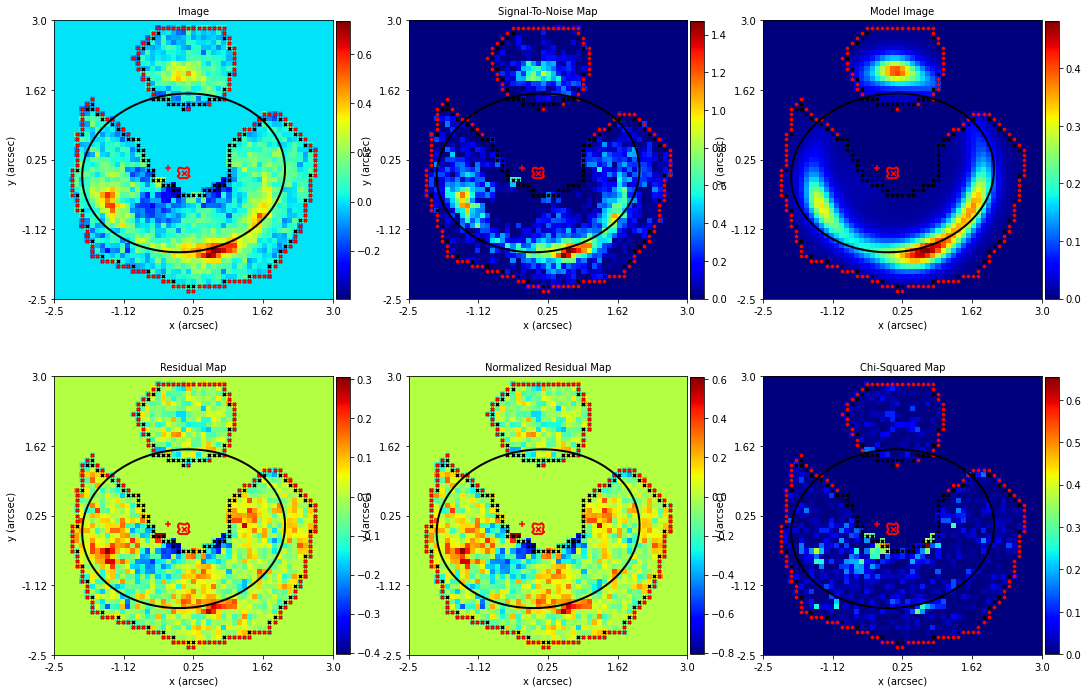

In [11]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()

In [ ]:
dynesty_plotter = aplt.DynestyPlotter(samples=result.samples)
dynesty_plotter.cornerplot()